# Лабораторная работа №1
## Классификация изображений фисташек на наборе Pistachio Image Dataset

**Дисциплина:** Компьютерное зрение  
**Тип задачи:** классификация изображений  
**Датасет:** `muratkokludataset/pistachio-image-dataset`

Цель лабораторной работы — построить полный исследовательский pipeline для задачи классификации изображений. В работе рассматриваются загрузка и анализ датасета, подготовка данных, обучение базовых и улучшенных моделей, сравнение сверточных и transformer-like архитектур, а также реализация собственной CNN-модели.

Данный набор данных выбран потому, что он связан с прикладными задачами агропромышленного контроля качества. Автоматическая классификация изображений фисташек может применяться для сортировки продукции, снижения доли ручного труда и повышения стабильности производственного контроля.

In [6]:
%pip install -q "urllib3<2" ipython ipywidgets jupyterlab_widgets widgetsnbextension kagglehub matplotlib numpy pandas pillow scikit-learn seaborn torch torchvision

You should consider upgrading via the '/Users/rkoyunusov/jupiter_rnd/venv/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [10]:
import copy
import math
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Tuple

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

## 1. Конфигурация эксперимента

В этом разделе задаются основные параметры лабораторной работы: размер изображения, batch size, число эпох, learning rate и random seed. Единая конфигурация делает эксперименты воспроизводимыми и упрощает сравнение моделей.

In [11]:
@dataclass
class Config:
    """Stores global experiment parameters used throughout the notebook."""

    seed: int = 42
    image_size: int = 224
    batch_size: int = 32
    num_workers: int = 0
    baseline_epochs: int = 5
    improved_epochs: int = 6
    custom_epochs: int = 8
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    train_size: float = 0.70
    val_size: float = 0.15
    test_size: float = 0.15
    checkpoint_dir: str = "checkpoints_lab1_pistachio"


CFG = Config()
print(asdict(CFG))

{'seed': 42, 'image_size': 224, 'batch_size': 32, 'num_workers': 0, 'baseline_epochs': 5, 'improved_epochs': 6, 'custom_epochs': 8, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'train_size': 0.7, 'val_size': 0.15, 'test_size': 0.15, 'checkpoint_dir': 'checkpoints_lab1_pistachio'}


## 2. Воспроизводимость и выбор устройства

Для корректного сравнения экспериментов необходимо фиксировать генераторы случайных чисел. Также автоматически выбирается доступное устройство: CUDA, Apple MPS или CPU. Это позволяет запускать ноутбук на разных машинах без изменения кода.

In [12]:
def set_seed(seed: int) -> None:
    """Fixes random seeds for Python, NumPy and PyTorch."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def get_device() -> torch.device:
    """Returns the best available torch device."""

    if torch.cuda.is_available():
        return torch.device("cuda")

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")


set_seed(CFG.seed)
DEVICE = get_device()
Path(CFG.checkpoint_dir).mkdir(parents=True, exist_ok=True)

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {DEVICE}")

Torch version: 2.8.0
Torchvision version: 0.23.0
Device: mps


## 3. Загрузка датасета

Датасет загружается через `kagglehub`. Это удобно для воспроизводимого эксперимента: путь к данным определяется автоматически, а сам код можно запускать на другой машине без ручной загрузки архива.

In [13]:
path = kagglehub.dataset_download("muratkokludataset/pistachio-image-dataset")
print("Path to dataset files:", path)

DATASET_ROOT = Path(path)
print("Dataset root:", DATASET_ROOT.resolve())

Path to dataset files: /Users/rkoyunusov/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1
Dataset root: /Users/rkoyunusov/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1


## 4. Структура датасета на диске

После загрузки через `kagglehub` изображения находятся не в корне архива, а во вложенной папке `Pistachio_Image_Dataset/Pistachio_Image_Dataset`.
Для обучения используются две папки-класса: `Kirmizi_Pistachio` и `Siirt_Pistachio`. Остальные файлы датасета содержат табличные признаки и описания, поэтому в pipeline классификации изображений они не используются.

In [14]:
IMAGE_DATASET_DIR = DATASET_ROOT / "Pistachio_Image_Dataset" / "Pistachio_Image_Dataset"

CLASS_DIRS = {
    "Kirmizi_Pistachio": IMAGE_DATASET_DIR / "Kirmizi_Pistachio",
    "Siirt_Pistachio": IMAGE_DATASET_DIR / "Siirt_Pistachio",
}

if not IMAGE_DATASET_DIR.exists():
    raise FileNotFoundError(f"Image dataset folder not found: {IMAGE_DATASET_DIR}")

for class_name, class_dir in CLASS_DIRS.items():
    if not class_dir.exists():
        raise FileNotFoundError(f"Class folder for {class_name} not found: {class_dir}")

print("Image dataset directory:", IMAGE_DATASET_DIR.resolve())
for class_name, class_dir in CLASS_DIRS.items():
    image_count = len(list(class_dir.glob("*.jpg")))
    print(f"{class_name:18s}: {image_count} jpg images")

Image dataset directory: /Users/rkoyunusov/.cache/kagglehub/datasets/muratkokludataset/pistachio-image-dataset/versions/1/Pistachio_Image_Dataset/Pistachio_Image_Dataset
Kirmizi_Pistachio : 1232 jpg images
Siirt_Pistachio   : 916 jpg images


## 5. Формирование списка изображений и меток

Так как схема датасета известна заранее, метка класса берется напрямую из имени папки. Это делает подготовку данных проще и прозрачнее: каждое изображение `*.jpg` из папки `Kirmizi_Pistachio` получает одноименную метку, аналогично для `Siirt_Pistachio`.

In [15]:
def collect_class_images(class_dirs: Dict[str, Path]) -> Dict[str, List[Path]]:
    """Collects image paths for the known Pistachio classes."""

    result: Dict[str, List[Path]] = {}
    for class_name, class_dir in class_dirs.items():
        images = sorted(class_dir.glob("*.jpg"))
        if len(images) == 0:
            raise RuntimeError(f"No jpg images found for class {class_name}: {class_dir}")

        result[class_name] = images

    return result


class_to_images = collect_class_images(CLASS_DIRS)
class_names = list(class_to_images.keys())
total_images = sum(len(images) for images in class_to_images.values())

print(f"Classes: {len(class_names)}")
for class_name, images in class_to_images.items():
    print(f"{class_name:30s}: {len(images)} images")

print(f"Total images: {total_images}")
print("Example files:")
for class_name, images in class_to_images.items():
    print(f"{class_name:30s}: {images[0].name}")

Classes: 2
Kirmizi_Pistachio             : 1232 images
Siirt_Pistachio               : 916 images
Total images: 2148
Example files:
Kirmizi_Pistachio             : kirmizi (1).jpg
Siirt_Pistachio               : siirt (1).jpg


## 6. Распределение классов

Анализ распределения классов нужен для понимания возможного дисбаланса. Если один класс сильно преобладает, accuracy может быть недостаточной метрикой, а обучение может требовать взвешенной функции потерь или балансировки.

,path,label
0,/Users/rkoyunusov/.cache/kagglehub/datasets/mu...,Kirmizi_Pistachio
1,/Users/rkoyunusov/.cache/kagglehub/datasets/mu...,Kirmizi_Pistachio
2,/Users/rkoyunusov/.cache/kagglehub/datasets/mu...,Kirmizi_Pistachio
3,/Users/rkoyunusov/.cache/kagglehub/datasets/mu...,Kirmizi_Pistachio
4,/Users/rkoyunusov/.cache/kagglehub/datasets/mu...,Kirmizi_Pistachio


label
Kirmizi_Pistachio    1232
Siirt_Pistachio       916
Name: count, dtype: int64

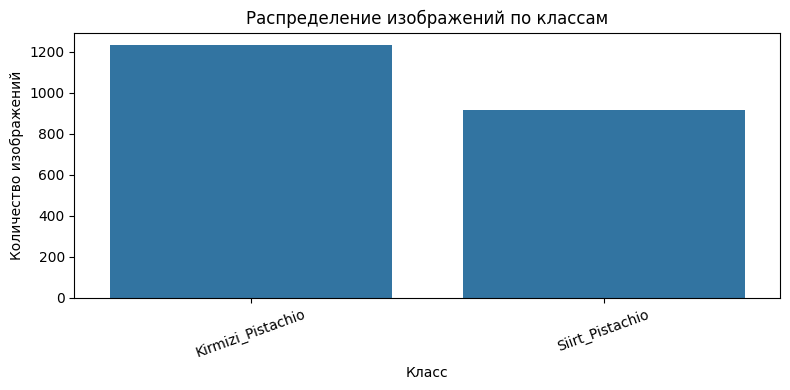

In [16]:
def build_image_dataframe(class_to_images: Dict[str, List[Path]]) -> pd.DataFrame:
    """Builds a dataframe with image paths and string labels."""

    rows = []
    for label, paths in class_to_images.items():
        for image_path in paths:
            rows.append({"path": str(image_path), "label": label})

    return pd.DataFrame(rows)


df = build_image_dataframe(class_to_images)
df["path"] = df["path"].astype(str)

display(df.head())
display(df["label"].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.title("Распределение изображений по классам")
plt.xlabel("Класс")
plt.ylabel("Количество изображений")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 7. Визуальная проверка изображений

Перед обучением модели полезно посмотреть примеры из каждого класса. Это позволяет убедиться, что данные загружены корректно, а классы действительно имеют визуальные различия.

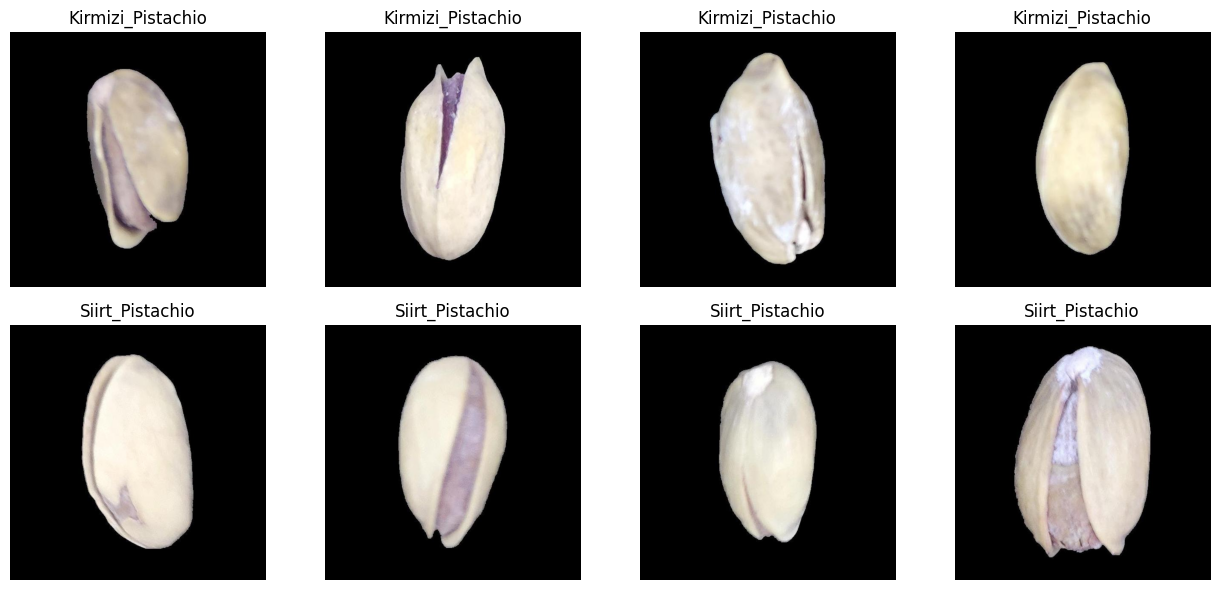

In [17]:
def show_class_samples(
    dataframe: pd.DataFrame,
    class_column: str = "label",
    path_column: str = "path",
    samples_per_class: int = 4,
    seed: int = 42,
) -> None:
    """Displays random sample images for every class."""

    rng = np.random.default_rng(seed)
    labels = sorted(dataframe[class_column].unique())
    n_rows = len(labels)
    n_cols = samples_per_class

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.0 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])
    if n_cols == 1:
        axes = axes.reshape(n_rows, 1)

    for row_idx, label in enumerate(labels):
        subset = dataframe[dataframe[class_column] == label]
        chosen_indices = rng.choice(
            subset.index,
            size=min(samples_per_class, len(subset)),
            replace=False,
        )

        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]
            ax.axis("off")

            if col_idx >= len(chosen_indices):
                continue

            image_path = dataframe.loc[chosen_indices[col_idx], path_column]
            image = Image.open(image_path).convert("RGB")
            ax.imshow(image)
            ax.set_title(label)

    plt.tight_layout()
    plt.show()


show_class_samples(df, samples_per_class=4, seed=CFG.seed)

## 8. Разбиение на train, validation и test

Используется стратифицированное разбиение 70/15/15. Обучающая выборка нужна для подбора весов модели, validation — для выбора лучшей эпохи и настройки экспериментов, test — только для финальной оценки качества. Стратификация сохраняет пропорции классов во всех частях данных.

In [18]:
def stratified_split_dataframe(
    dataframe: pd.DataFrame,
    label_column: str,
    train_size: float,
    val_size: float,
    test_size: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Splits dataframe into stratified train, validation and test parts."""

    total = train_size + val_size + test_size
    if not math.isclose(total, 1.0, abs_tol=1e-6):
        raise ValueError("train_size + val_size + test_size must be equal to 1.0")

    train_df, temp_df = train_test_split(
        dataframe,
        train_size=train_size,
        stratify=dataframe[label_column],
        random_state=seed,
    )

    relative_val_size = val_size / (val_size + test_size)
    val_df, test_df = train_test_split(
        temp_df,
        train_size=relative_val_size,
        stratify=temp_df[label_column],
        random_state=seed,
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


train_df, val_df, test_df = stratified_split_dataframe(
    df,
    label_column="label",
    train_size=CFG.train_size,
    val_size=CFG.val_size,
    test_size=CFG.test_size,
    seed=CFG.seed,
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

split_distribution = pd.DataFrame(
    {
        "train": train_df["label"].value_counts(),
        "validation": val_df["label"].value_counts(),
        "test": test_df["label"].value_counts(),
    }
).fillna(0).astype(int)

display(split_distribution)

Train size: 1503
Validation size: 322
Test size: 323


,train,validation,test
label,,,
Kirmizi_Pistachio,862,185,185
Siirt_Pistachio,641,137,138


## 9. PyTorch Dataset и преобразования изображений

Для базового эксперимента применяются стандартные преобразования: изменение размера, случайное горизонтальное отражение и нормализация ImageNet. Это разумный старт, потому что модели из `torchvision` обычно предварительно обучались на ImageNet и ожидают похожую нормализацию входа.

In [19]:
label_to_idx = {label: idx for idx, label in enumerate(sorted(df["label"].unique()))}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
num_classes = len(label_to_idx)

print("Label mapping:")
for label, idx in label_to_idx.items():
    print(f"{idx}: {label}")


class PistachioDataset(Dataset):
    """PyTorch dataset for image classification from a dataframe."""

    def __init__(
        self,
        dataframe: pd.DataFrame,
        label_to_idx: Dict[str, int],
        transform: Optional[Callable] = None,
    ) -> None:
        """Initializes dataset with paths, labels and optional transforms."""

        self.dataframe = dataframe.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self) -> int:
        """Returns dataset length."""

        return len(self.dataframe)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int, str]:
        """Loads an image and returns tensor, numeric label and image path."""

        row = self.dataframe.iloc[index]
        image_path = row["path"]
        label_name = row["label"]

        image = Image.open(image_path).convert("RGB")
        label = self.label_to_idx[label_name]

        if self.transform is not None:
            image = self.transform(image)

        return image, label, image_path


def get_baseline_transforms(image_size: int) -> Tuple[Callable, Callable]:
    """Returns baseline train and evaluation transforms."""

    train_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
    )

    eval_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
    )

    return train_transform, eval_transform


baseline_train_transform, baseline_eval_transform = get_baseline_transforms(CFG.image_size)

Label mapping:
0: Kirmizi_Pistachio
1: Siirt_Pistachio


## 10. DataLoader

`DataLoader` формирует mini-batch для обучения. Для train-набора включается перемешивание, чтобы модель не зависела от порядка файлов. Для validation и test перемешивание не нужно, так как эти наборы используются только для оценки.
В notebook-окружении на macOS оставляем `num_workers=0`: при multiprocessing Python пытается сериализовать класс `PistachioDataset` из `__main__`, что может приводить к ошибке `Can't get attribute 'PistachioDataset'`.

In [21]:
def create_dataloaders(
    train_dataframe: pd.DataFrame,
    val_dataframe: pd.DataFrame,
    test_dataframe: pd.DataFrame,
    label_to_idx: Dict[str, int],
    train_transform: Callable,
    eval_transform: Callable,
    batch_size: int,
    num_workers: int,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """Creates train, validation and test dataloaders."""

    train_dataset = PistachioDataset(train_dataframe, label_to_idx, train_transform)
    val_dataset = PistachioDataset(val_dataframe, label_to_idx, eval_transform)
    test_dataset = PistachioDataset(test_dataframe, label_to_idx, eval_transform)

    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = create_dataloaders(
    train_df,
    val_df,
    test_df,
    label_to_idx,
    baseline_train_transform,
    baseline_eval_transform,
    CFG.batch_size,
    CFG.num_workers,
)

batch_images, batch_labels, batch_paths = next(iter(train_loader))
print("Batch images:", batch_images.shape)
print("Batch labels:", batch_labels.shape)

Batch images: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32])


## 11. Метрики качества

Для оценки используются accuracy, precision, recall и F1-score. Accuracy показывает общую долю правильных ответов, но при дисбалансе классов может быть недостаточной. Precision и recall показывают разные типы ошибок, а F1 объединяет их в одну метрику. Для бинарной классификации код корректно использует binary-режим, для многоклассовой — macro-усреднение.

In [22]:
def compute_classification_metrics(
    y_true: List[int],
    y_pred: List[int],
    num_classes: int,
) -> Dict[str, float]:
    """Computes accuracy, precision, recall and F1 for binary or multiclass classification."""

    average = "binary" if num_classes == 2 else "macro"
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=average,
        zero_division=0,
    )

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }


def print_metrics(metrics: Dict[str, float], prefix: str = "") -> None:
    """Prints metric dictionary in a readable form."""

    text_prefix = f"{prefix} " if prefix else ""
    for name, value in metrics.items():
        print(f"{text_prefix}{name}: {value:.4f}")


sample_metrics = compute_classification_metrics([0, 1, 1, 0], [0, 1, 0, 0], num_classes=2)
print_metrics(sample_metrics, prefix="Example")

Example accuracy: 0.7500
Example precision: 1.0000
Example recall: 0.5000
Example f1: 0.6667


## 12. Вспомогательные функции обучения и оценки

Ниже реализован основной training loop. Он сохраняет checkpoint лучшей модели по validation F1, так как F1 более информативен при возможном дисбалансе классов. Функции сделаны универсальными, чтобы их можно было использовать для разных архитектур и экспериментов.

In [23]:
def move_batch_to_device(
    images: torch.Tensor,
    labels: torch.Tensor,
    device: torch.device,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Moves image and label tensors to selected device."""

    return images.to(device), labels.to(device)


def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
) -> float:
    """Runs one training epoch and returns average loss."""

    model.train()
    running_loss = 0.0
    total_samples = 0

    for images, labels, _ in dataloader:
        images, labels = move_batch_to_device(images, labels, device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    return running_loss / max(total_samples, 1)


@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    num_classes: int,
) -> Tuple[float, Dict[str, float], List[int], List[int], List[str]]:
    """Evaluates model and returns loss, metrics, predictions, labels and paths."""

    model.eval()
    running_loss = 0.0
    total_samples = 0

    all_labels: List[int] = []
    all_predictions: List[int] = []
    all_paths: List[str] = []

    for images, labels, paths in dataloader:
        images, labels = move_batch_to_device(images, labels, device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        predictions = torch.argmax(outputs, dim=1)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_predictions.extend(predictions.detach().cpu().numpy().tolist())
        all_paths.extend(list(paths))

    avg_loss = running_loss / max(total_samples, 1)
    metrics = compute_classification_metrics(all_labels, all_predictions, num_classes)

    return avg_loss, metrics, all_predictions, all_labels, all_paths


def train_model(
    model: nn.Module,
    train_dataloader: DataLoader,
    val_dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    num_classes: int,
    epochs: int,
    checkpoint_path: Path,
    scheduler: Optional[Any] = None,
) -> Tuple[nn.Module, pd.DataFrame]:
    """Trains a model, tracks validation metrics and restores best checkpoint."""

    model = model.to(device)
    best_f1 = -1.0
    best_state = copy.deepcopy(model.state_dict())
    history_rows = []

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_loss = train_one_epoch(model, train_dataloader, criterion, optimizer, device)
        val_loss, val_metrics, _, _, _ = evaluate_model(
            model,
            val_dataloader,
            criterion,
            device,
            num_classes,
        )

        if scheduler is not None:
            scheduler.step()

        epoch_time = time.time() - start_time

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "epoch_time_sec": epoch_time,
        }
        history_rows.append(row)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, checkpoint_path)

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history_rows)

## 13. Визуализация истории обучения

Графики loss и метрик позволяют оценить динамику обучения. Если training loss падает, а validation loss растет, это может указывать на переобучение. Если обе кривые почти не меняются, возможно, модели не хватает емкости или неправильно выбран learning rate.

In [24]:
def plot_training_history(history: pd.DataFrame, title: str) -> None:
    """Plots loss, validation accuracy and validation F1 curves."""

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="Train loss")
    axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="Validation loss")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(history["epoch"], history["val_accuracy"], marker="o", label="Validation accuracy")
    axes[1].plot(history["epoch"], history["val_f1"], marker="o", label="Validation F1")
    axes[1].set_title(f"{title}: metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(
    y_true: List[int],
    y_pred: List[int],
    idx_to_label: Dict[int, str],
    title: str,
) -> None:
    """Plots confusion matrix heatmap."""

    labels = [idx_to_label[idx] for idx in range(len(idx_to_label))]
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

## 14. Создание CNN baseline на основе ResNet-18

В качестве первой базовой модели используется ResNet-18 из `torchvision`. Это классическая сверточная архитектура, которая хорошо подходит как сильный baseline для задач классификации изображений. Последний классификационный слой заменяется под число классов текущего датасета.

In [25]:
def create_resnet18_model(num_classes: int, pretrained: bool = True) -> nn.Module:
    """Creates a ResNet-18 classifier with a replaced final layer."""

    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


resnet_baseline = create_resnet18_model(num_classes=num_classes, pretrained=True)
print(resnet_baseline.__class__.__name__)
print("Number of classes:", num_classes)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/rkoyunusov/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|████████████████████████████████████████████████| 44.7M/44.7M [00:19<00:00, 2.45MB/s]


ResNet
Number of classes: 2


## 15. Обучение CNN baseline

Для базовой модели используется AdamW и CrossEntropyLoss. Число эпох намеренно небольшое, чтобы лабораторную работу можно было выполнить за разумное время. Лучший checkpoint выбирается по validation F1.

Epoch 01/5 | train_loss=0.1715 | val_loss=0.0373 | val_acc=0.9876 | val_f1=0.9856 | time=14.6s
Epoch 02/5 | train_loss=0.0410 | val_loss=0.0374 | val_acc=0.9845 | val_f1=0.9815 | time=8.7s
Epoch 03/5 | train_loss=0.0313 | val_loss=0.0297 | val_acc=0.9907 | val_f1=0.9889 | time=8.6s
Epoch 04/5 | train_loss=0.0223 | val_loss=0.0174 | val_acc=1.0000 | val_f1=1.0000 | time=8.6s
Epoch 05/5 | train_loss=0.0308 | val_loss=0.0773 | val_acc=0.9658 | val_f1=0.9614 | time=8.7s


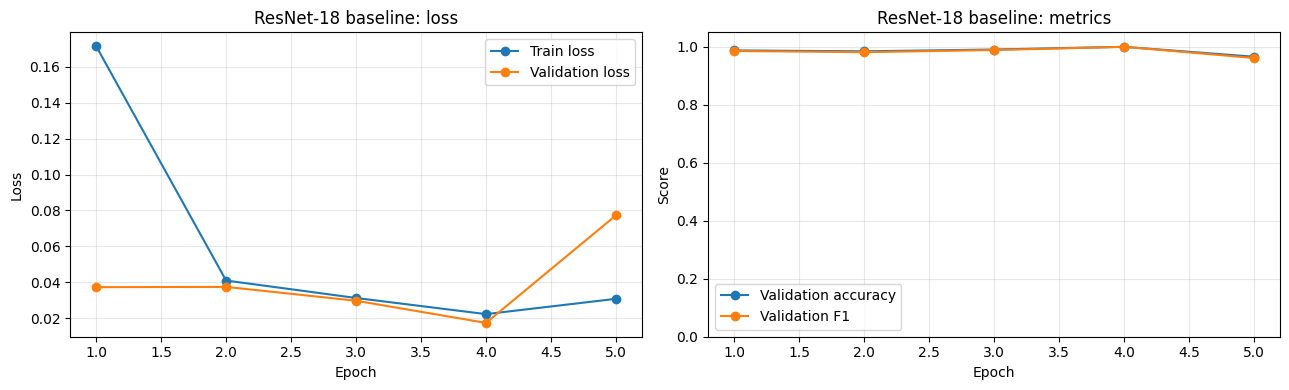

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    resnet_baseline.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

resnet_checkpoint = Path(CFG.checkpoint_dir) / "resnet18_baseline.pt"

resnet_baseline, resnet_history = train_model(
    model=resnet_baseline,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    num_classes=num_classes,
    epochs=CFG.baseline_epochs,
    checkpoint_path=resnet_checkpoint,
)

plot_training_history(resnet_history, "ResNet-18 baseline")

## 16. Оценка CNN baseline на test-наборе

Test-набор используется только после выбора лучшей эпохи на validation. Это дает более честную оценку качества модели на данных, которые не участвовали в обучении и подборе checkpoint.

Test loss: 0.0637
ResNet-18 baseline test accuracy: 0.9721
ResNet-18 baseline test precision: 0.9708
ResNet-18 baseline test recall: 0.9638
ResNet-18 baseline test f1: 0.9673

Classification report:
                   precision    recall  f1-score   support

Kirmizi_Pistachio       0.97      0.98      0.98       185
  Siirt_Pistachio       0.97      0.96      0.97       138

         accuracy                           0.97       323
        macro avg       0.97      0.97      0.97       323
     weighted avg       0.97      0.97      0.97       323



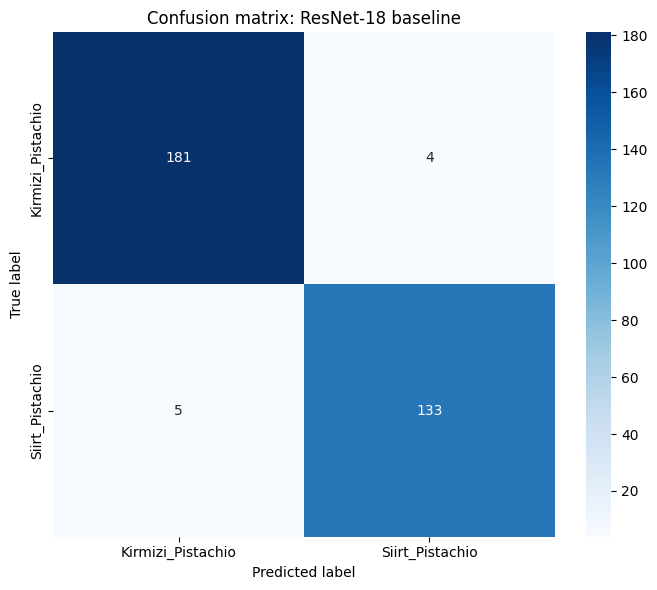

In [28]:
resnet_test_loss, resnet_test_metrics, resnet_test_pred, resnet_test_true, resnet_test_paths = evaluate_model(
    resnet_baseline,
    test_loader,
    criterion,
    DEVICE,
    num_classes,
)

print(f"Test loss: {resnet_test_loss:.4f}")
print_metrics(resnet_test_metrics, prefix="ResNet-18 baseline test")

print("\nClassification report:")
print(
    classification_report(
        resnet_test_true,
        resnet_test_pred,
        target_names=[idx_to_label[idx] for idx in range(num_classes)],
        zero_division=0,
    )
)

plot_confusion_matrix(
    resnet_test_true,
    resnet_test_pred,
    idx_to_label,
    title="Confusion matrix: ResNet-18 baseline",
)

## 17. Просмотр корректных и ошибочных предсказаний

Анализ отдельных изображений помогает понять характер ошибок модели. Например, ошибки могут возникать из-за похожих визуальных признаков классов, плохого освещения или нестандартного положения объекта.

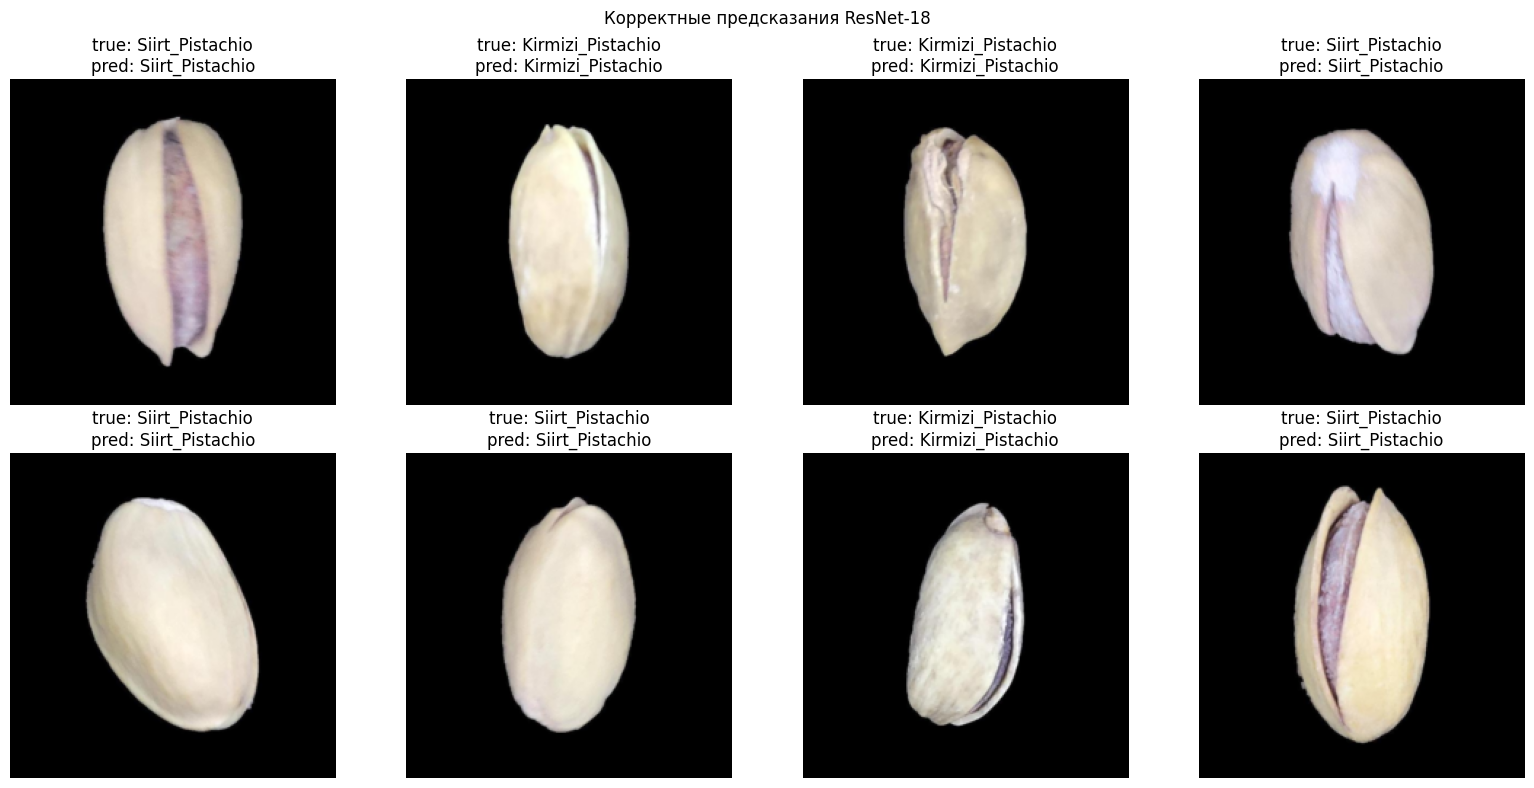

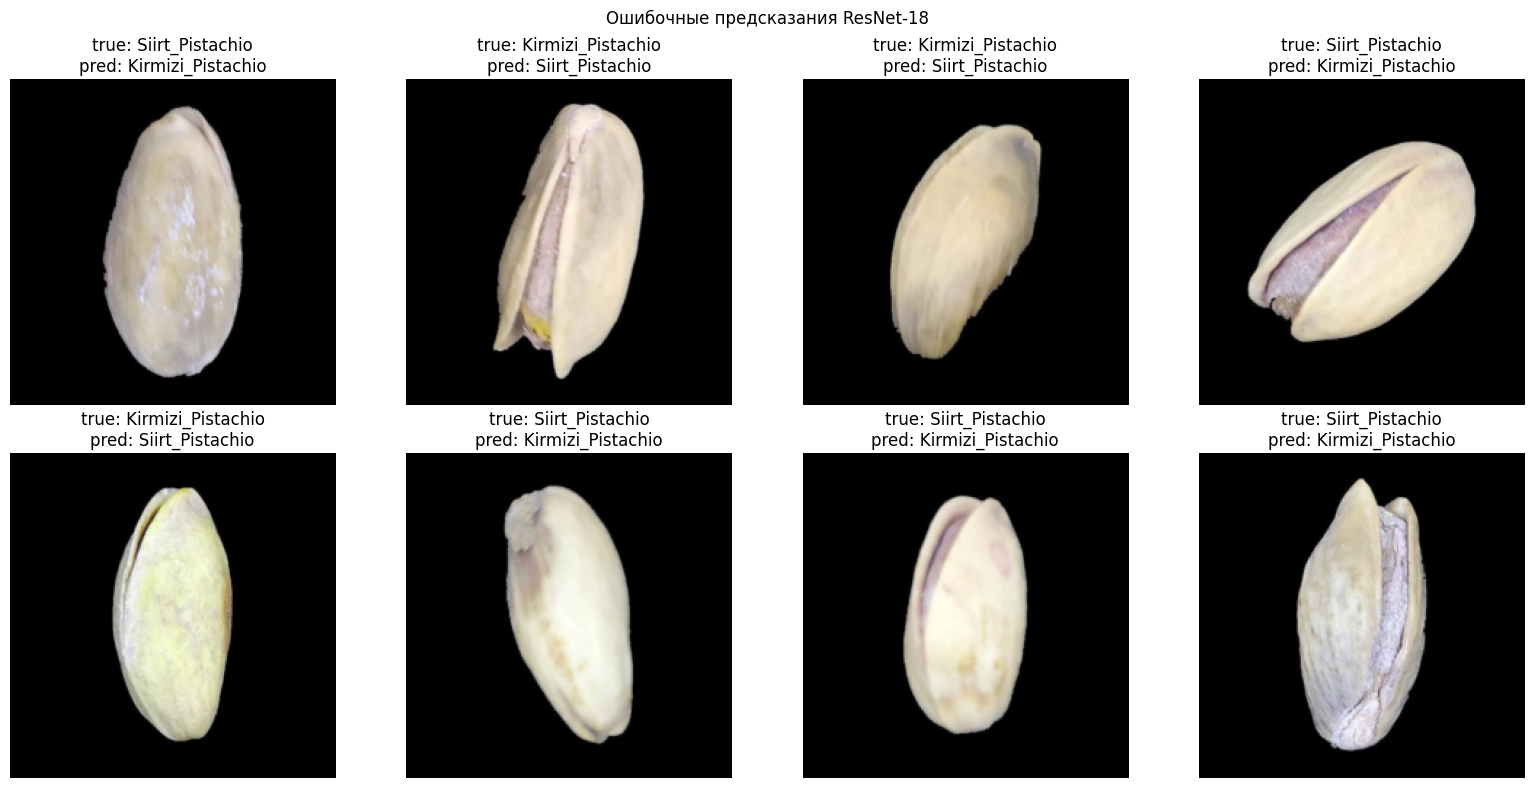

In [29]:
def denormalize_image(tensor: torch.Tensor) -> np.ndarray:
    """Converts a normalized tensor image back to a displayable NumPy image."""

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = tensor.detach().cpu() * std + mean
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return image


@torch.no_grad()
def collect_prediction_examples(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    max_examples: int = 8,
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    """Collects correct and incorrect prediction examples."""

    model.eval()
    correct_examples: List[Dict[str, Any]] = []
    wrong_examples: List[Dict[str, Any]] = []

    for images, labels, paths in dataloader:
        images_device = images.to(device)
        outputs = model(images_device)
        predictions = torch.argmax(outputs, dim=1).detach().cpu()

        for idx in range(images.size(0)):
            item = {
                "image": images[idx],
                "true": int(labels[idx]),
                "pred": int(predictions[idx]),
                "path": paths[idx],
            }

            if item["true"] == item["pred"] and len(correct_examples) < max_examples:
                correct_examples.append(item)

            if item["true"] != item["pred"] and len(wrong_examples) < max_examples:
                wrong_examples.append(item)

            if len(correct_examples) >= max_examples and len(wrong_examples) >= max_examples:
                return correct_examples, wrong_examples

    return correct_examples, wrong_examples


def show_prediction_grid(
    examples: List[Dict[str, Any]],
    idx_to_label: Dict[int, str],
    title: str,
    columns: int = 4,
) -> None:
    """Shows a grid of prediction examples."""

    if len(examples) == 0:
        print(f"No examples to show for: {title}")
        return

    rows = math.ceil(len(examples) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.array(axes).reshape(rows, columns)

    for ax in axes.ravel():
        ax.axis("off")

    for ax, item in zip(axes.ravel(), examples):
        ax.imshow(denormalize_image(item["image"]))
        true_label = idx_to_label[item["true"]]
        pred_label = idx_to_label[item["pred"]]
        ax.set_title(f"true: {true_label}\npred: {pred_label}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


correct_examples, wrong_examples = collect_prediction_examples(
    resnet_baseline,
    test_loader,
    DEVICE,
    max_examples=8,
)

show_prediction_grid(correct_examples, idx_to_label, "Корректные предсказания ResNet-18")
show_prediction_grid(wrong_examples, idx_to_label, "Ошибочные предсказания ResNet-18")

## 18. Transformer-like модель

Для сравнения с CNN попробуем использовать vision transformer из `torchvision`, если он доступен в текущей версии библиотеки. Transformer-like модели обрабатывают изображение через патчи и attention-механизм. Для fallback'а можно юзать EfficientNet-B0 как сильную альтернативу из `torchvision`.

In [30]:
def create_transformer_like_model(num_classes: int) -> Tuple[nn.Module, str]:
    """Creates a ViT model if available, otherwise falls back to EfficientNet-B0."""

    if hasattr(models, "vit_b_16"):
        try:
            weights = models.ViT_B_16_Weights.DEFAULT
            model = models.vit_b_16(weights=weights)
            in_features = model.heads.head.in_features
            model.heads.head = nn.Linear(in_features, num_classes)
            return model, "ViT-B-16"
        except Exception as exc:
            print(f"ViT creation failed, fallback will be used. Reason: {exc}")

    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model, "EfficientNet-B0 fallback"


transformer_like_model, transformer_like_name = create_transformer_like_model(num_classes)
print("Selected model:", transformer_like_name)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/rkoyunusov/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████████████████████████████████████████████| 330M/330M [02:50<00:00, 2.03MB/s]


Selected model: ViT-B-16


## 19. Обучение и оценка transformer-like модели

Модель обучается тем же pipeline, что и CNN baseline. Это важно для честного сравнения: меняется архитектура, но схема подготовки данных, loss, optimizer и метрики остаются одинаковыми.

Epoch 01/5 | train_loss=0.3261 | val_loss=0.2562 | val_acc=0.8882 | val_f1=0.8824 | time=56.7s
Epoch 02/5 | train_loss=0.0841 | val_loss=0.0845 | val_acc=0.9658 | val_f1=0.9600 | time=55.0s
Epoch 03/5 | train_loss=0.0905 | val_loss=0.1807 | val_acc=0.9472 | val_f1=0.9349 | time=54.9s
Epoch 04/5 | train_loss=0.0441 | val_loss=0.1590 | val_acc=0.9472 | val_f1=0.9408 | time=54.1s
Epoch 05/5 | train_loss=0.0738 | val_loss=0.1511 | val_acc=0.9503 | val_f1=0.9385 | time=51.3s


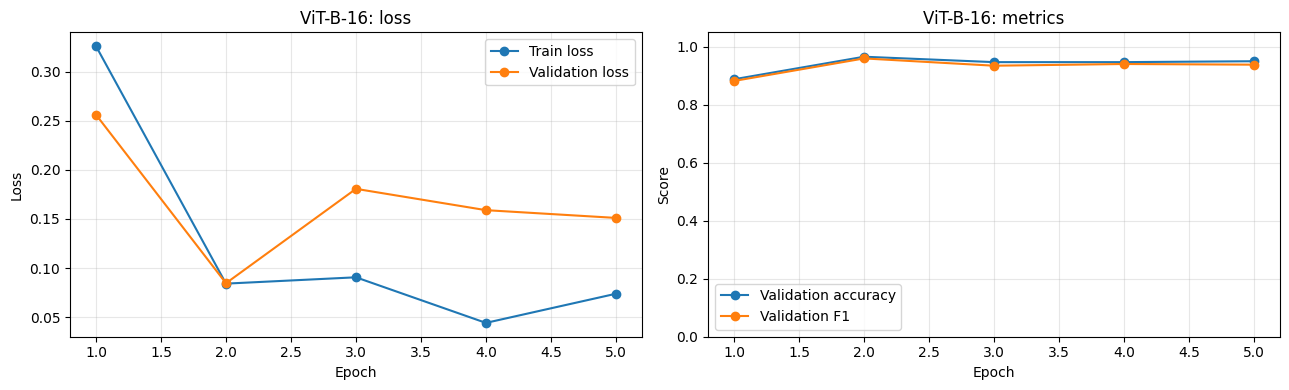

Test loss: 0.0608
ViT-B-16 test accuracy: 0.9845
ViT-B-16 test precision: 0.9854
ViT-B-16 test recall: 0.9783
ViT-B-16 test f1: 0.9818


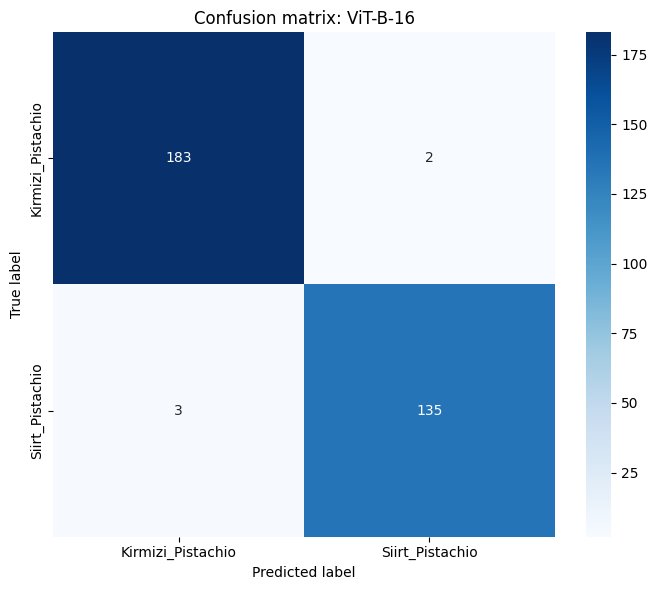

In [31]:
transformer_optimizer = optim.AdamW(
    transformer_like_model.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

transformer_checkpoint = Path(CFG.checkpoint_dir) / "transformer_like_baseline.pt"

transformer_like_model, transformer_history = train_model(
    model=transformer_like_model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    criterion=criterion,
    optimizer=transformer_optimizer,
    device=DEVICE,
    num_classes=num_classes,
    epochs=CFG.baseline_epochs,
    checkpoint_path=transformer_checkpoint,
)

plot_training_history(transformer_history, transformer_like_name)

transformer_test_loss, transformer_test_metrics, transformer_test_pred, transformer_test_true, _ = evaluate_model(
    transformer_like_model,
    test_loader,
    criterion,
    DEVICE,
    num_classes,
)

print(f"Test loss: {transformer_test_loss:.4f}")
print_metrics(transformer_test_metrics, prefix=f"{transformer_like_name} test")

plot_confusion_matrix(
    transformer_test_true,
    transformer_test_pred,
    idx_to_label,
    title=f"Confusion matrix: {transformer_like_name}",
)

## 20. Первичное сравнение baseline-моделей

На этом этапе сравниваются две готовые архитектуры: сверточная ResNet-18 и transformer-like модель. Результат позволяет понять, какая архитектура лучше подходит для дальнейших улучшений на данном датасете.

,model,test_loss,accuracy,precision,recall,f1
0,ResNet-18 baseline,0.063724,0.972136,0.970803,0.963768,0.967273
1,ViT-B-16 baseline,0.060776,0.984520,0.985401,0.978261,0.981818


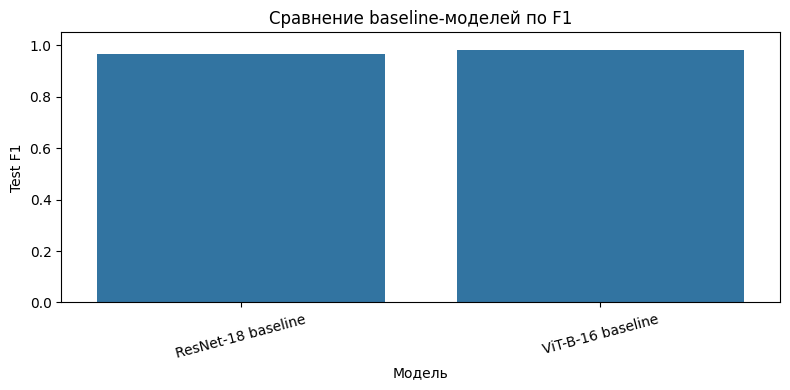

In [32]:
baseline_comparison = pd.DataFrame(
    [
        {
            "model": "ResNet-18 baseline",
            "test_loss": resnet_test_loss,
            **resnet_test_metrics,
        },
        {
            "model": f"{transformer_like_name} baseline",
            "test_loss": transformer_test_loss,
            **transformer_test_metrics,
        },
    ]
)

display(baseline_comparison)

plt.figure(figsize=(8, 4))
sns.barplot(data=baseline_comparison, x="model", y="f1")
plt.title("Сравнение baseline-моделей по F1")
plt.xlabel("Модель")
plt.ylabel("Test F1")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 21. Гипотезы для улучшения

Дальше проверяются несколько исследовательских гипотез. Это не гарантирует улучшение в каждом эксперименте: на маленьком наборе данных более сложная регуляризация иногда может ухудшать результат.

1. **Более сильные аугментации могут улучшить обобщающую способность**, так как модель увидит больше вариаций положения, масштаба и цвета.
2. **Scheduler learning rate может улучшить сходимость**, потому что learning rate постепенно уменьшается и модель точнее дообучается в конце.
3. **Учет дисбаланса классов может быть полезен**, если один класс представлен заметно меньше другого.

Для практической части реализуются два улучшения: сильные аугментации и взвешенная функция потерь с scheduler.

## 22. Улучшение №1: более сильные аугментации

В этом эксперименте к базовым transforms добавляются повороты, изменение цвета и небольшая перспективная деформация. Такие преобразования должны сделать модель менее чувствительной к условиям съемки.

Epoch 01/6 | train_loss=0.2584 | val_loss=0.1051 | val_acc=0.9596 | val_f1=0.9524 | time=11.3s
Epoch 02/6 | train_loss=0.1021 | val_loss=0.0352 | val_acc=0.9907 | val_f1=0.9889 | time=10.4s
Epoch 03/6 | train_loss=0.1128 | val_loss=0.0404 | val_acc=0.9876 | val_f1=0.9854 | time=10.3s
Epoch 04/6 | train_loss=0.0614 | val_loss=0.0472 | val_acc=0.9876 | val_f1=0.9856 | time=10.6s
Epoch 05/6 | train_loss=0.0667 | val_loss=0.0275 | val_acc=0.9907 | val_f1=0.9889 | time=10.5s
Epoch 06/6 | train_loss=0.0560 | val_loss=0.0948 | val_acc=0.9627 | val_f1=0.9542 | time=10.4s


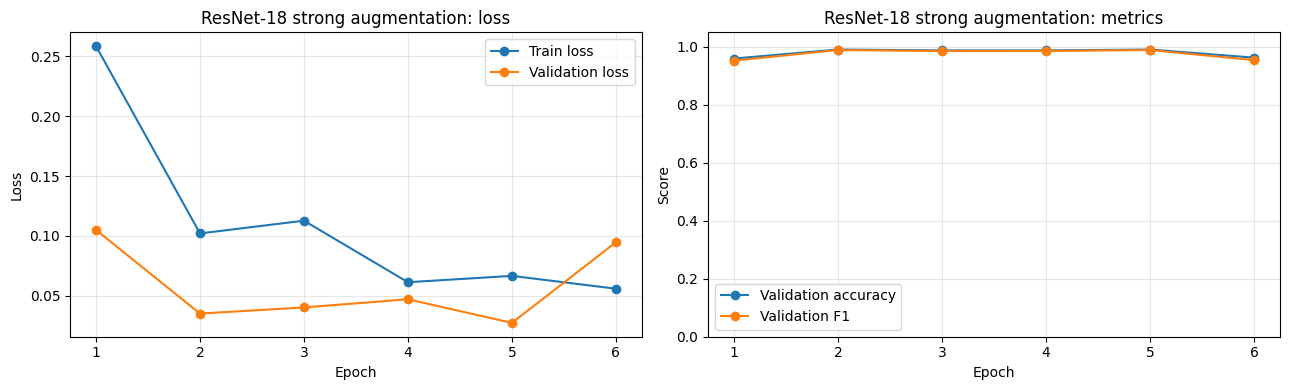

Test loss: 0.0722
ResNet-18 strong augmentation test accuracy: 0.9814
ResNet-18 strong augmentation test precision: 1.0000
ResNet-18 strong augmentation test recall: 0.9565
ResNet-18 strong augmentation test f1: 0.9778


In [33]:
def get_strong_augmentation_transforms(image_size: int) -> Tuple[Callable, Callable]:
    """Returns stronger train transforms and standard evaluation transforms."""

    train_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.12,
                hue=0.03,
            ),
            transforms.RandomPerspective(distortion_scale=0.15, p=0.25),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
    )

    eval_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
    )

    return train_transform, eval_transform


strong_train_transform, strong_eval_transform = get_strong_augmentation_transforms(CFG.image_size)

strong_train_loader, strong_val_loader, strong_test_loader = create_dataloaders(
    train_df,
    val_df,
    test_df,
    label_to_idx,
    strong_train_transform,
    strong_eval_transform,
    CFG.batch_size,
    CFG.num_workers,
)

resnet_augmented = create_resnet18_model(num_classes=num_classes, pretrained=True)
resnet_augmented_optimizer = optim.AdamW(
    resnet_augmented.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

resnet_augmented_checkpoint = Path(CFG.checkpoint_dir) / "resnet18_strong_aug.pt"

resnet_augmented, resnet_augmented_history = train_model(
    model=resnet_augmented,
    train_dataloader=strong_train_loader,
    val_dataloader=strong_val_loader,
    criterion=criterion,
    optimizer=resnet_augmented_optimizer,
    device=DEVICE,
    num_classes=num_classes,
    epochs=CFG.improved_epochs,
    checkpoint_path=resnet_augmented_checkpoint,
)

plot_training_history(resnet_augmented_history, "ResNet-18 strong augmentation")

resnet_aug_test_loss, resnet_aug_test_metrics, resnet_aug_pred, resnet_aug_true, _ = evaluate_model(
    resnet_augmented,
    strong_test_loader,
    criterion,
    DEVICE,
    num_classes,
)

print(f"Test loss: {resnet_aug_test_loss:.4f}")
print_metrics(resnet_aug_test_metrics, prefix="ResNet-18 strong augmentation test")

## 23. Улучшение №2: class weights и scheduler

Если классы представлены неравномерно, модель может чаще выбирать более многочисленный класс. Взвешенная CrossEntropyLoss увеличивает вклад ошибок на редких классах. Дополнительно применяется CosineAnnealingLR, который плавно уменьшает learning rate во время обучения.

Class weights: [0.8718097 1.1723869]
Epoch 01/6 | train_loss=0.2313 | val_loss=0.1556 | val_acc=0.9317 | val_f1=0.9257 | time=10.7s
Epoch 02/6 | train_loss=0.1022 | val_loss=0.0642 | val_acc=0.9783 | val_f1=0.9745 | time=10.3s
Epoch 03/6 | train_loss=0.0907 | val_loss=0.0676 | val_acc=0.9658 | val_f1=0.9614 | time=10.5s
Epoch 04/6 | train_loss=0.0470 | val_loss=0.0332 | val_acc=0.9876 | val_f1=0.9855 | time=10.5s
Epoch 05/6 | train_loss=0.0452 | val_loss=0.0331 | val_acc=0.9845 | val_f1=0.9821 | time=10.4s
Epoch 06/6 | train_loss=0.0447 | val_loss=0.0121 | val_acc=1.0000 | val_f1=1.0000 | time=10.4s


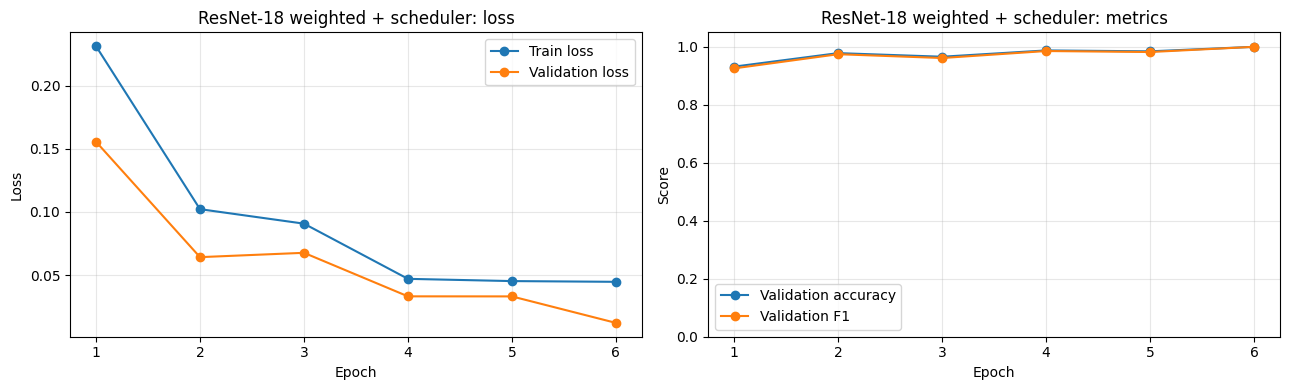

Test loss: 0.0478
ResNet-18 weighted + scheduler test accuracy: 0.9814
ResNet-18 weighted + scheduler test precision: 0.9925
ResNet-18 weighted + scheduler test recall: 0.9638
ResNet-18 weighted + scheduler test f1: 0.9779


In [34]:
def compute_class_weights(train_dataframe: pd.DataFrame, label_to_idx: Dict[str, int]) -> torch.Tensor:
    """Computes inverse-frequency class weights from the train dataframe."""

    counts = train_dataframe["label"].value_counts().to_dict()
    total = len(train_dataframe)
    weights = []

    for label, idx in sorted(label_to_idx.items(), key=lambda item: item[1]):
        count = counts.get(label, 1)
        weight = total / (len(label_to_idx) * count)
        weights.append(weight)

    return torch.tensor(weights, dtype=torch.float32)


class_weights = compute_class_weights(train_df, label_to_idx).to(DEVICE)
print("Class weights:", class_weights.detach().cpu().numpy())

weighted_criterion = nn.CrossEntropyLoss(weight=class_weights)

resnet_weighted = create_resnet18_model(num_classes=num_classes, pretrained=True)
resnet_weighted_optimizer = optim.AdamW(
    resnet_weighted.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)
resnet_weighted_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    resnet_weighted_optimizer,
    T_max=CFG.improved_epochs,
)

resnet_weighted_checkpoint = Path(CFG.checkpoint_dir) / "resnet18_weighted_scheduler.pt"

resnet_weighted, resnet_weighted_history = train_model(
    model=resnet_weighted,
    train_dataloader=strong_train_loader,
    val_dataloader=strong_val_loader,
    criterion=weighted_criterion,
    optimizer=resnet_weighted_optimizer,
    device=DEVICE,
    num_classes=num_classes,
    epochs=CFG.improved_epochs,
    checkpoint_path=resnet_weighted_checkpoint,
    scheduler=resnet_weighted_scheduler,
)

plot_training_history(resnet_weighted_history, "ResNet-18 weighted + scheduler")

resnet_weighted_test_loss, resnet_weighted_test_metrics, resnet_weighted_pred, resnet_weighted_true, _ = evaluate_model(
    resnet_weighted,
    strong_test_loader,
    weighted_criterion,
    DEVICE,
    num_classes,
)

print(f"Test loss: {resnet_weighted_test_loss:.4f}")
print_metrics(resnet_weighted_test_metrics, prefix="ResNet-18 weighted + scheduler test")

## 24. Выбор лучшей модели среди torchvision-экспериментов

Теперь сравним ResNet-18 baseline, два улучшенных варианта ResNet-18 и ViT-B-16. Лучшей считается модель с максимальным test F1. В текущем запуске это важно, потому что лучший результат может показать не улучшенный ResNet, а отдельная transformer-like архитектура.

In [35]:
torchvision_results = pd.DataFrame(
    [
        {
            "model": "ResNet-18 baseline",
            "experiment_type": "torchvision",
            "test_loss": resnet_test_loss,
            **resnet_test_metrics,
        },
        {
            "model": "ResNet-18 strong augmentation",
            "experiment_type": "torchvision",
            "test_loss": resnet_aug_test_loss,
            **resnet_aug_test_metrics,
        },
        {
            "model": "ResNet-18 weighted + scheduler",
            "experiment_type": "torchvision",
            "test_loss": resnet_weighted_test_loss,
            **resnet_weighted_test_metrics,
        },
        {
            "model": f"{transformer_like_name} baseline",
            "experiment_type": "torchvision",
            "test_loss": transformer_test_loss,
            **transformer_test_metrics,
        },
    ]
).sort_values("f1", ascending=False)

display(torchvision_results)

best_torchvision_row = torchvision_results.iloc[0]
print("Best torchvision setup:")
display(best_torchvision_row.to_frame().T)

,model,experiment_type,test_loss,accuracy,precision,recall,f1
3,ViT-B-16 baseline,torchvision,0.060776,0.984520,0.985401,0.978261,0.981818
2,ResNet-18 weighted + scheduler,torchvision,0.047797,0.981424,0.992537,0.963768,0.977941
1,ResNet-18 strong augmentation,torchvision,0.072156,0.981424,1.000000,0.956522,0.977778
0,ResNet-18 baseline,torchvision,0.063724,0.972136,0.970803,0.963768,0.967273


Best torchvision setup:


,model,experiment_type,test_loss,accuracy,precision,recall,f1
3,ViT-B-16 baseline,torchvision,0.060776,0.98452,0.985401,0.978261,0.981818


## 25. Собственная CNN-модель

Помимо готовых архитектур важно реализовать простую модель вручную. Это помогает понять базовые компоненты CNN: сверточные слои, BatchNorm, ReLU, pooling и классификационную голову. Такая модель обычно слабее pretrained-сетей, но полезна как учебный baseline.

In [36]:
class SimpleCustomCNN(nn.Module):
    """A simple manually implemented convolutional neural network."""

    def __init__(self, num_classes: int) -> None:
        """Initializes convolutional feature extractor and classifier."""

        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.35),
            nn.Linear(192, 96),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.20),
            nn.Linear(96, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Runs forward pass."""

        x = self.features(x)
        x = self.classifier(x)
        return x


custom_baseline = SimpleCustomCNN(num_classes=num_classes)
print(custom_baseline)

SimpleCustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(192, eps=1e-05, momentum=0

## 26. Обучение собственной CNN без улучшений

Сначала собственная модель обучается на базовых transforms 8 эпох. Это позволяет получить честный custom baseline, который затем можно сравнить с улучшенной версией той же архитектуры.

Epoch 01/8 | train_loss=0.3762 | val_loss=0.3711 | val_acc=0.8571 | val_f1=0.8051 | time=6.2s
Epoch 02/8 | train_loss=0.3259 | val_loss=0.3263 | val_acc=0.8820 | val_f1=0.8504 | time=6.1s
Epoch 03/8 | train_loss=0.3128 | val_loss=0.3552 | val_acc=0.8447 | val_f1=0.7899 | time=6.1s
Epoch 04/8 | train_loss=0.2640 | val_loss=0.2714 | val_acc=0.8820 | val_f1=0.8492 | time=6.2s
Epoch 05/8 | train_loss=0.2387 | val_loss=0.5200 | val_acc=0.7516 | val_f1=0.5876 | time=6.1s
Epoch 06/8 | train_loss=0.2138 | val_loss=0.3137 | val_acc=0.8571 | val_f1=0.8562 | time=6.2s
Epoch 07/8 | train_loss=0.2083 | val_loss=0.2098 | val_acc=0.9193 | val_f1=0.9103 | time=6.2s
Epoch 08/8 | train_loss=0.1681 | val_loss=0.2893 | val_acc=0.8727 | val_f1=0.8690 | time=6.2s


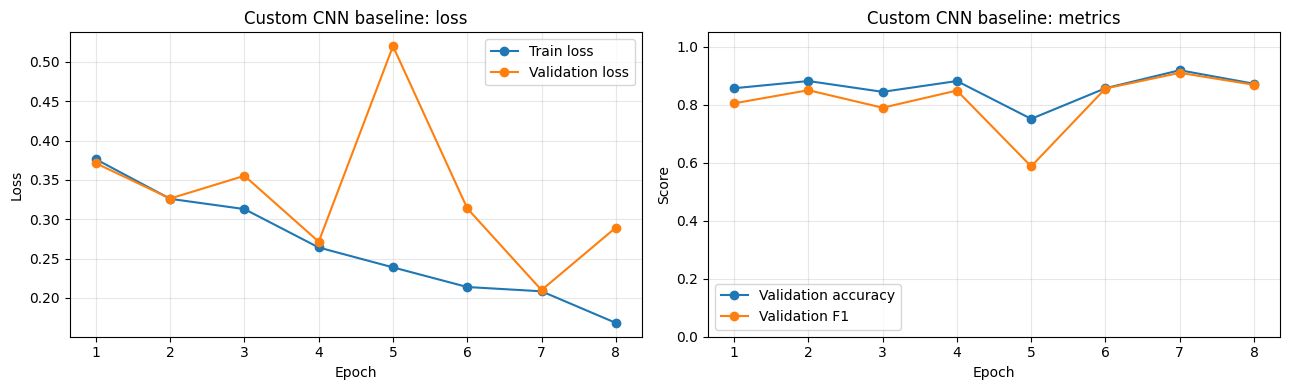

Test loss: 0.2055
Custom CNN baseline test accuracy: 0.9195
Custom CNN baseline test precision: 0.8636
Custom CNN baseline test recall: 0.9638
Custom CNN baseline test f1: 0.9110


In [38]:
custom_baseline_optimizer = optim.AdamW(
    custom_baseline.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

custom_baseline_checkpoint = Path(CFG.checkpoint_dir) / "custom_cnn_baseline.pt"

custom_baseline, custom_baseline_history = train_model(
    model=custom_baseline,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    criterion=criterion,
    optimizer=custom_baseline_optimizer,
    device=DEVICE,
    num_classes=num_classes,
    epochs=CFG.custom_epochs,
    checkpoint_path=custom_baseline_checkpoint,
)

plot_training_history(custom_baseline_history, "Custom CNN baseline")

custom_baseline_test_loss, custom_baseline_test_metrics, custom_baseline_pred, custom_baseline_true, _ = evaluate_model(
    custom_baseline,
    test_loader,
    criterion,
    DEVICE,
    num_classes,
)

print(f"Test loss: {custom_baseline_test_loss:.4f}")
print_metrics(custom_baseline_test_metrics, prefix="Custom CNN baseline test")

## 27. Улучшенная собственная CNN

К собственной модели применяются сильные аугментации, weighted loss и scheduler. Этот эксперимент проверяет, помогают ли такие настройки архитектуре, обучаемой практически с нуля; по итоговым метрикам видно, что для простой CNN такая комбинация оказалась слишком агрессивной.

Epoch 01/6 | train_loss=0.6714 | val_loss=0.6524 | val_acc=0.4814 | val_f1=0.6213 | time=8.0s
Epoch 02/6 | train_loss=0.6314 | val_loss=0.5919 | val_acc=0.8416 | val_f1=0.8172 | time=8.0s
Epoch 03/6 | train_loss=0.5995 | val_loss=0.6348 | val_acc=0.6149 | val_f1=0.1733 | time=8.1s
Epoch 04/6 | train_loss=0.5649 | val_loss=0.5381 | val_acc=0.7950 | val_f1=0.8024 | time=8.1s
Epoch 05/6 | train_loss=0.5426 | val_loss=0.5134 | val_acc=0.8230 | val_f1=0.7782 | time=8.1s
Epoch 06/6 | train_loss=0.5273 | val_loss=0.5107 | val_acc=0.8168 | val_f1=0.7686 | time=8.1s


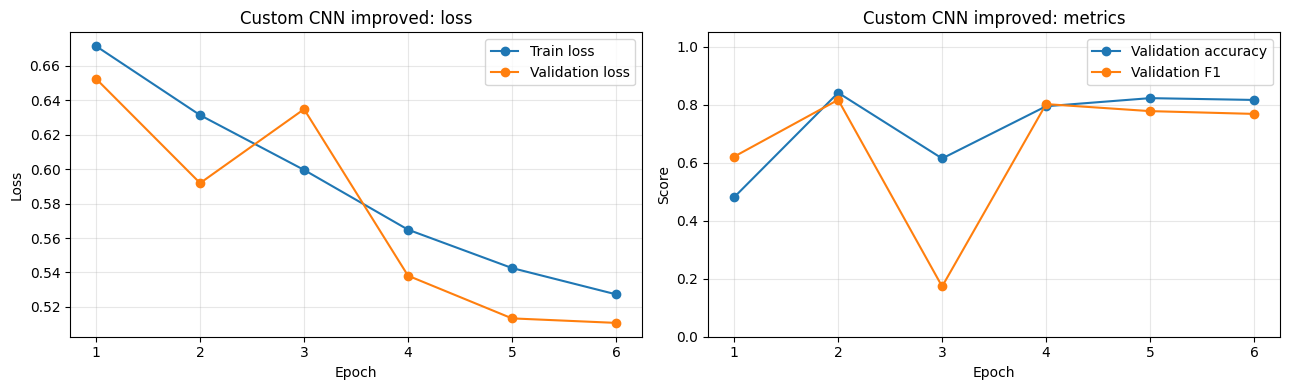

Test loss: 0.5989
Custom CNN improved test accuracy: 0.8173
Custom CNN improved test precision: 0.8211
Custom CNN improved test recall: 0.7319
Custom CNN improved test f1: 0.7739


In [39]:
custom_improved = SimpleCustomCNN(num_classes=num_classes)
custom_improved_optimizer = optim.AdamW(
    custom_improved.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)
custom_improved_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    custom_improved_optimizer,
    T_max=CFG.improved_epochs,
)

custom_improved_checkpoint = Path(CFG.checkpoint_dir) / "custom_cnn_improved.pt"

custom_improved, custom_improved_history = train_model(
    model=custom_improved,
    train_dataloader=strong_train_loader,
    val_dataloader=strong_val_loader,
    criterion=weighted_criterion,
    optimizer=custom_improved_optimizer,
    device=DEVICE,
    num_classes=num_classes,
    epochs=CFG.improved_epochs,
    checkpoint_path=custom_improved_checkpoint,
    scheduler=custom_improved_scheduler,
)

plot_training_history(custom_improved_history, "Custom CNN improved")

custom_improved_test_loss, custom_improved_test_metrics, custom_improved_pred, custom_improved_true, _ = evaluate_model(
    custom_improved,
    strong_test_loader,
    weighted_criterion,
    DEVICE,
    num_classes,
)

print(f"Test loss: {custom_improved_test_loss:.4f}")
print_metrics(custom_improved_test_metrics, prefix="Custom CNN improved test")

## 28. Итоговое сравнение моделей

В финальной таблице сравниваются все основные эксперименты: ResNet-18 baseline, два улучшенных варианта ResNet-18, ViT-B-16, собственная CNN и улучшенная собственная CNN. В текущем запуске лучший test F1 показывает ViT-B-16 baseline, а среди ResNet-вариантов лидирует weighted + scheduler.

,model,group,test_loss,accuracy,precision,recall,f1
5,ViT-B-16 baseline,transformer_like,0.060776,0.984520,0.985401,0.978261,0.981818
4,ResNet-18 weighted + scheduler,torchvision,0.047797,0.981424,0.992537,0.963768,0.977941
3,ResNet-18 strong augmentation,torchvision,0.072156,0.981424,1.000000,0.956522,0.977778
2,ResNet-18 baseline,torchvision,0.063724,0.972136,0.970803,0.963768,0.967273
0,Custom CNN baseline,custom,0.205528,0.919505,0.863636,0.963768,0.910959
1,Custom CNN improved,custom,0.598893,0.817337,0.821138,0.731884,0.773946


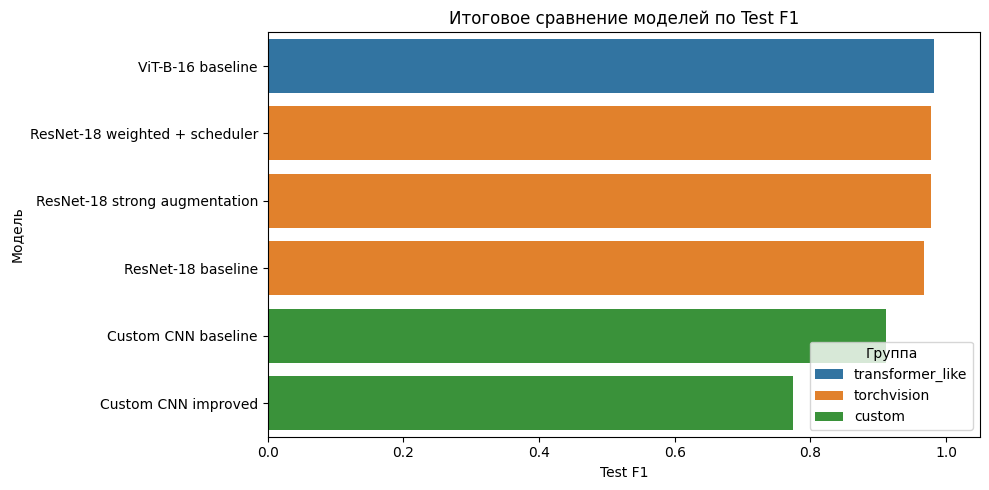

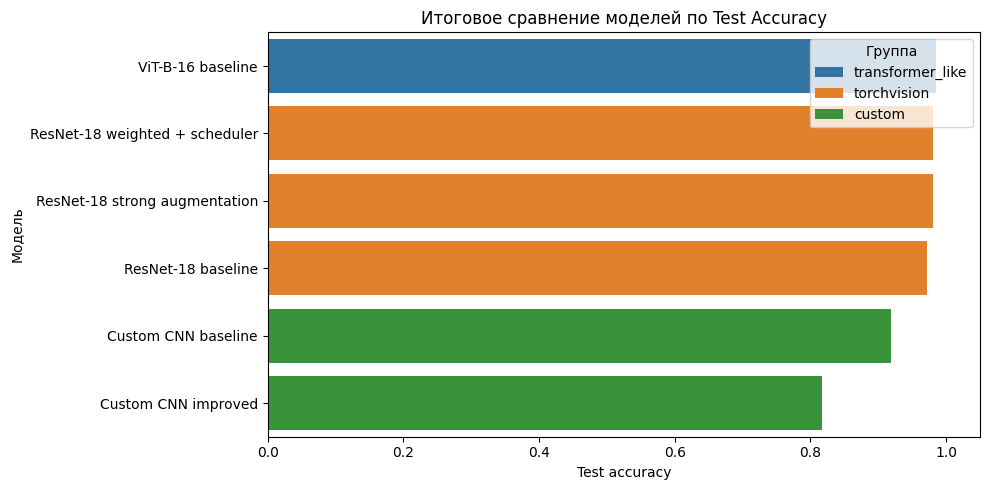

In [40]:
final_results = pd.DataFrame(
    [
        {
            "model": "Custom CNN baseline",
            "group": "custom",
            "test_loss": custom_baseline_test_loss,
            **custom_baseline_test_metrics,
        },
        {
            "model": "Custom CNN improved",
            "group": "custom",
            "test_loss": custom_improved_test_loss,
            **custom_improved_test_metrics,
        },
        {
            "model": "ResNet-18 baseline",
            "group": "torchvision",
            "test_loss": resnet_test_loss,
            **resnet_test_metrics,
        },
        {
            "model": "ResNet-18 strong augmentation",
            "group": "torchvision",
            "test_loss": resnet_aug_test_loss,
            **resnet_aug_test_metrics,
        },
        {
            "model": "ResNet-18 weighted + scheduler",
            "group": "torchvision",
            "test_loss": resnet_weighted_test_loss,
            **resnet_weighted_test_metrics,
        },
        {
            "model": f"{transformer_like_name} baseline",
            "group": "transformer_like",
            "test_loss": transformer_test_loss,
            **transformer_test_metrics,
        },
    ]
).sort_values("f1", ascending=False)

display(final_results)

plt.figure(figsize=(10, 5))
sns.barplot(data=final_results, x="f1", y="model", hue="group", dodge=False)
plt.title("Итоговое сравнение моделей по Test F1")
plt.xlabel("Test F1")
plt.ylabel("Модель")
plt.xlim(0, 1.05)
plt.legend(title="Группа")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=final_results, x="accuracy", y="model", hue="group", dodge=False)
plt.title("Итоговое сравнение моделей по Test Accuracy")
plt.xlabel("Test accuracy")
plt.ylabel("Модель")
plt.xlim(0, 1.05)
plt.legend(title="Группа")
plt.tight_layout()
plt.show()

## 29. Confusion matrix для лучшей модели

Для лучшей модели дополнительно строится confusion matrix. Она показывает, какие классы чаще всего путаются между собой. Это особенно важно в прикладной задаче сортировки, где разные типы ошибок могут иметь разную стоимость.

Best model: ViT-B-16 baseline


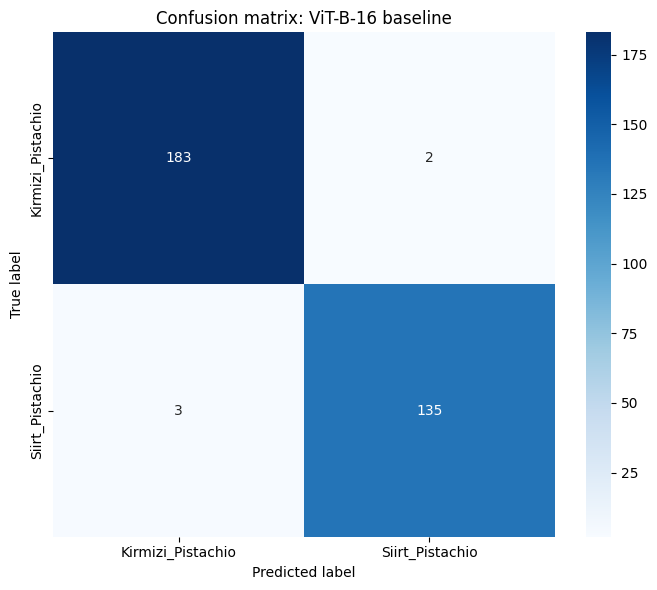

In [41]:
def select_best_model_predictions(
    final_results: pd.DataFrame,
) -> Tuple[str, List[int], List[int]]:
    """Selects stored predictions for the best model from final result table."""

    best_model_name = str(final_results.iloc[0]["model"])

    prediction_map = {
        "Custom CNN baseline": (custom_baseline_true, custom_baseline_pred),
        "Custom CNN improved": (custom_improved_true, custom_improved_pred),
        "ResNet-18 baseline": (resnet_test_true, resnet_test_pred),
        "ResNet-18 strong augmentation": (resnet_aug_true, resnet_aug_pred),
        "ResNet-18 weighted + scheduler": (resnet_weighted_true, resnet_weighted_pred),
        f"{transformer_like_name} baseline": (transformer_test_true, transformer_test_pred),
    }

    y_true, y_pred = prediction_map[best_model_name]
    return best_model_name, y_true, y_pred


best_model_name, best_true, best_pred = select_best_model_predictions(final_results)

print("Best model:", best_model_name)
plot_confusion_matrix(
    best_true,
    best_pred,
    idx_to_label,
    title=f"Confusion matrix: {best_model_name}",
)

## 30. Ошибочные предсказания лучшей доступной обученной модели

Для лучшей модели дополнительно выводится сетка ошибочных предсказаний. В текущем запуске лучшей стала `ViT-B-16 baseline`, поэтому ниже анализируются именно ее ошибки.

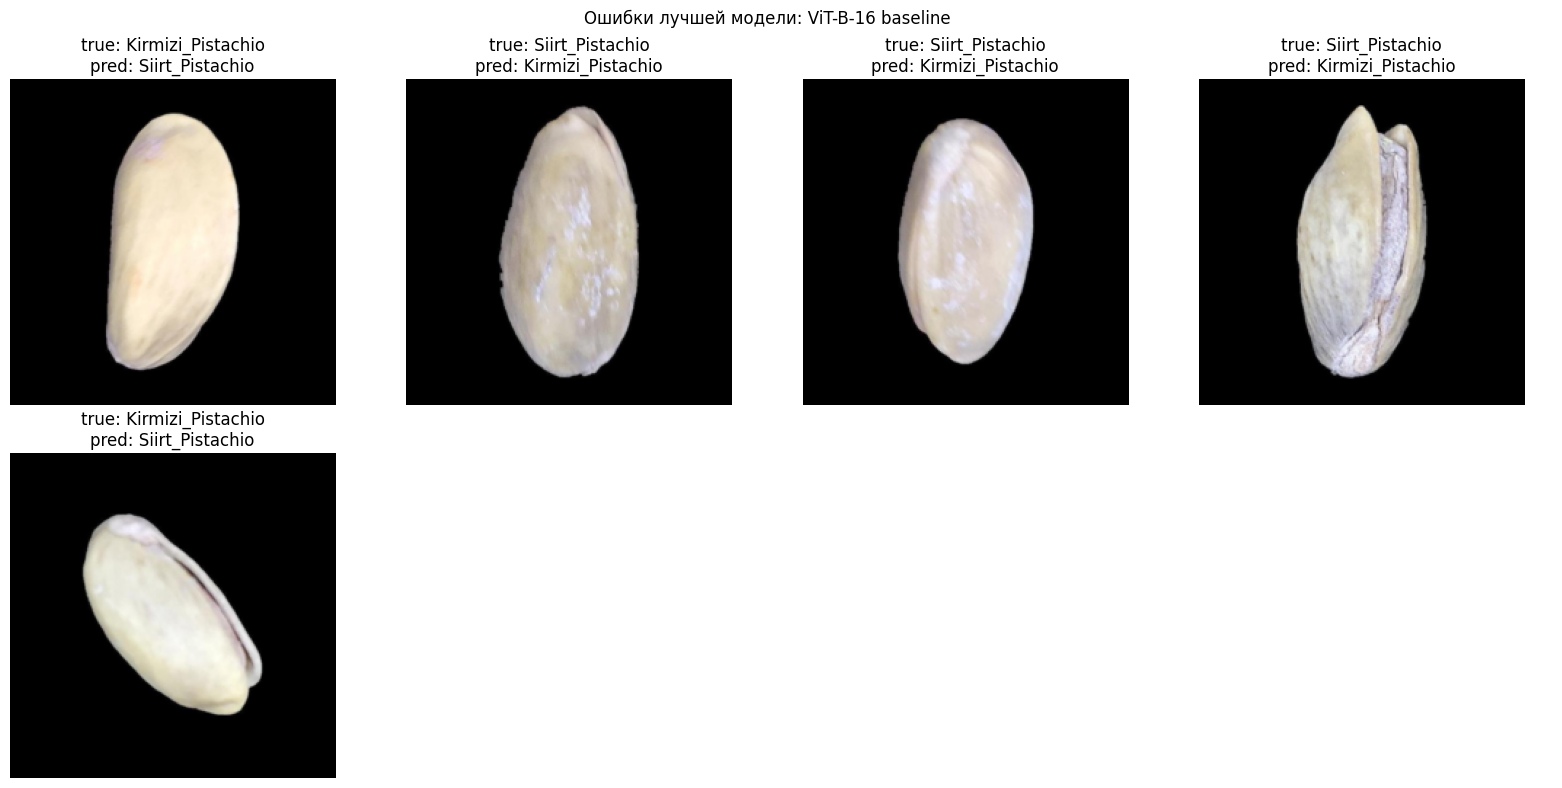

In [42]:
def get_model_object_by_name(model_name: str) -> Optional[nn.Module]:
    """Returns an already trained model object by its displayed name."""

    model_map = {
        "Custom CNN baseline": custom_baseline,
        "Custom CNN improved": custom_improved,
        "ResNet-18 baseline": resnet_baseline,
        "ResNet-18 strong augmentation": resnet_augmented,
        "ResNet-18 weighted + scheduler": resnet_weighted,
        f"{transformer_like_name} baseline": transformer_like_model,
    }

    return model_map.get(model_name)


def get_loader_by_model_name(model_name: str) -> DataLoader:
    """Returns an evaluation dataloader matching model preprocessing."""

    if model_name in {
        "Custom CNN improved",
        "ResNet-18 strong augmentation",
        "ResNet-18 weighted + scheduler",
    }:
        return strong_test_loader

    return test_loader


best_model_object = get_model_object_by_name(best_model_name)
best_model_loader = get_loader_by_model_name(best_model_name)

if best_model_object is not None:
    _, best_wrong_examples = collect_prediction_examples(
        best_model_object,
        best_model_loader,
        DEVICE,
        max_examples=8,
    )
    show_prediction_grid(best_wrong_examples, idx_to_label, f"Ошибки лучшей модели: {best_model_name}")

## 31. Выводы

В ходе лабораторной работы был построен полный pipeline классификации изображений для Pistachio Image Dataset. После загрузки через `kagglehub` использовалась известная структура датасета: 1232 изображения `Kirmizi_Pistachio` и 916 изображений `Siirt_Pistachio`, всего 2148 изображений. Данные были стратифицированно разделены на train/validation/test в пропорции 70/15/15.

Лучший результат на test-наборе показала `ViT-B-16 baseline`: accuracy = 0.9845, precision = 0.9854, recall = 0.9783, F1 = 0.9818. Среди ResNet-18 вариантов лучшим оказался эксперимент `weighted + scheduler` с F1 = 0.9779; он немного обошел ResNet-18 baseline с F1 = 0.9673 и strong augmentation с F1 = 0.9778.

Собственная CNN без предобучения заметно уступила pretrained-моделям, но дала рабочий baseline: F1 = 0.9110. Улучшенная версия собственной CNN с сильными аугментациями, weighted loss и scheduler в этом запуске сработала хуже: F1 = 0.7739. Это показывает, что приемы, полезные для pretrained ResNet, не всегда напрямую переносятся на небольшую модель, обучаемую почти с нуля.

Практический вывод: для этого датасета transfer learning дает самый стабильный результат, а лучшей архитектурой в текущем эксперименте стала ViT-B-16. Для дальнейшего улучшения стоит подбирать learning rate и силу аугментаций отдельно для каждой архитектуры, а не переносить один и тот же набор улучшений на все модели.